# 07 - Noise Models and Filter Matching

Gaussian noise is modeled as an additive random variable \(n\sim\mathcal{N}(0,\sigma_n^2)\). Salt-and-pepper noise replaces a fraction \(p\) of pixels with extreme values. Mean, median, and Gaussian filters are compared under both disturbances.

In [1]:
from pathlib import Path
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

def find_course_root() -> Path:
    """Locate the cloned course repository without a machine-specific path."""
    candidates = []
    configured = os.environ.get("VISION_ROBOTICA_REPO")
    if configured:
        candidates.append(Path(configured).expanduser())
    current = Path.cwd().resolve()
    candidates.extend([current, *current.parents])
    for candidate in candidates:
        if (candidate / "imagenes").is_dir() and (candidate / "requirements.txt").is_file():
            return candidate
    raise FileNotFoundError(
        "Course repository not found. Run the notebook from the cloned repository root "
        "or define VISION_ROBOTICA_REPO."
    )

ROOT = find_course_root()
COURSE_IMAGES = ROOT / "imagenes"
STUDENT_IMAGES = ROOT / "student_work" / "imagenes"
STUDENT_IMAGES.mkdir(parents=True, exist_ok=True)

def load_rgb(filename: str) -> np.ndarray:
    path = COURSE_IMAGES / filename
    image_bgr = cv2.imread(str(path), cv2.IMREAD_COLOR)
    if image_bgr is None:
        raise FileNotFoundError(f"Official course image not found: {path}")
    return cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

print(f"Course root: {ROOT}")
print(f"Official images: {COURSE_IMAGES}")
print(f"Student images: {STUDENT_IMAGES}")

Course root: C:\Users\20808\Documents\Repositorios\Vision_en_Robotica
Official images: C:\Users\20808\Documents\Repositorios\Vision_en_Robotica\imagenes
Student images: C:\Users\20808\Documents\Repositorios\Vision_en_Robotica\student_work\imagenes


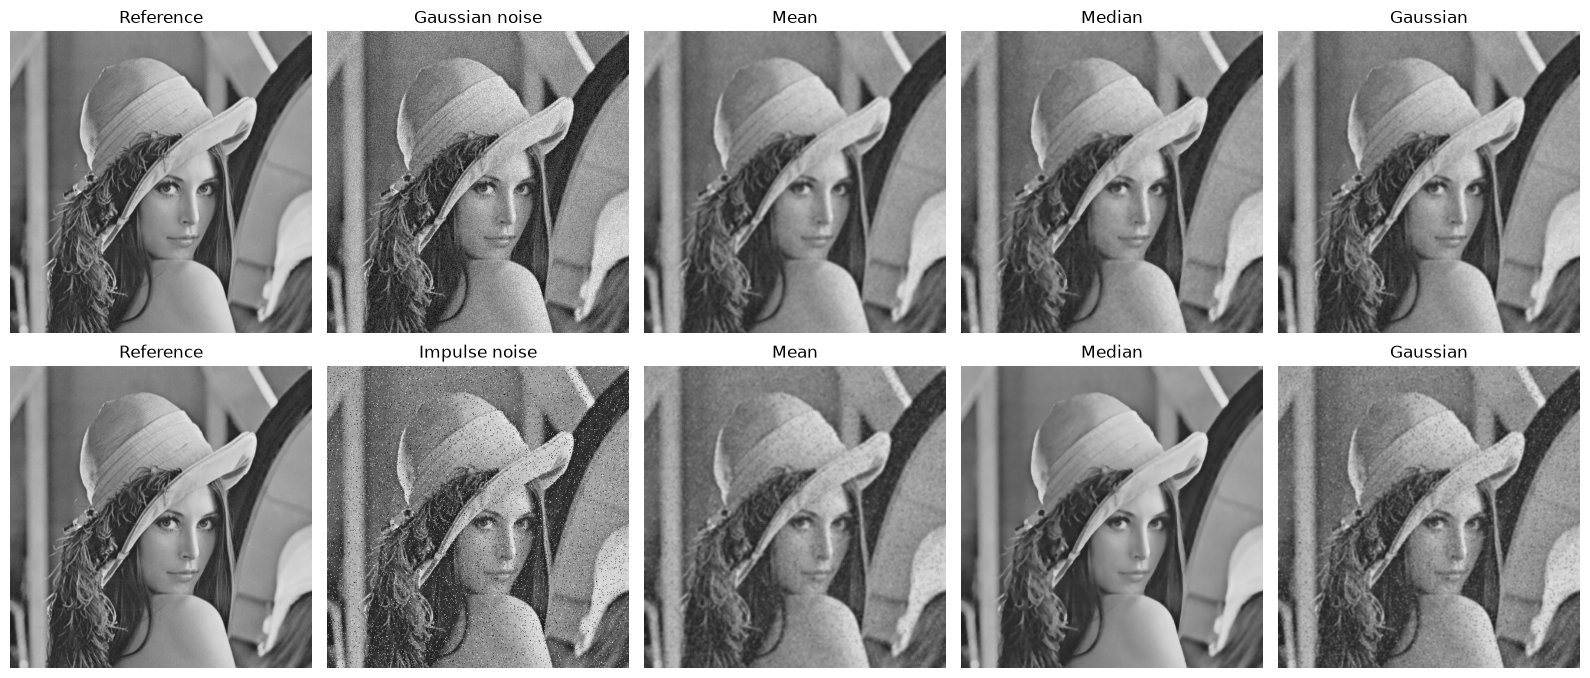

In [2]:
image_rgb = load_rgb("lenna.png")
gray = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2GRAY)
rng = np.random.default_rng(4012)

sigma_noise = 18.0
gaussian_noise = rng.normal(0.0, sigma_noise, gray.shape)
gaussian_noisy = np.clip(gray.astype(np.float32) + gaussian_noise, 0, 255).astype(np.uint8)

impulse_probability = 0.06
impulse_noisy = gray.copy()
random_map = rng.random(gray.shape)
impulse_noisy[random_map < impulse_probability / 2] = 0
impulse_noisy[(random_map >= impulse_probability / 2) & (random_map < impulse_probability)] = 255

def filter_set(image: np.ndarray) -> dict[str, np.ndarray]:
    return {
        "Mean": cv2.blur(image, (5, 5)),
        "Median": cv2.medianBlur(image, 5),
        "Gaussian": cv2.GaussianBlur(image, (5, 5), 1.2),
    }

experiments = {"Gaussian noise": gaussian_noisy, "Impulse noise": impulse_noisy}
fig, axes = plt.subplots(2, 5, figsize=(16, 7))
for row, (noise_name, noisy) in enumerate(experiments.items()):
    images = {"Reference": gray, noise_name: noisy, **filter_set(noisy)}
    for axis, (title, image) in zip(axes[row], images.items()):
        axis.imshow(image, cmap="gray", vmin=0, vmax=255)
        axis.set_title(title)
        axis.axis("off")
plt.tight_layout()
plt.show()

In [3]:
def mse(reference: np.ndarray, test: np.ndarray) -> float:
    difference = reference.astype(np.float32) - test.astype(np.float32)
    return float(np.mean(difference**2))

for noise_name, noisy in experiments.items():
    print(f"\n{noise_name}")
    print(f"{'Result':10s} {'MSE':>10s} {'Gradient ratio':>16s}")
    reference_grad = cv2.Laplacian(gray, cv2.CV_32F).var()
    for name, image in {"Noisy": noisy, **filter_set(noisy)}.items():
        gradient_ratio = cv2.Laplacian(image, cv2.CV_32F).var() / reference_grad
        print(f"{name:10s} {mse(gray, image):10.2f} {gradient_ratio:16.3f}")


Gaussian noise
Result            MSE   Gradient ratio
Noisy          323.12           17.627
Mean            84.27            0.099
Median          76.93            0.373
Gaussian        59.67            0.106

Impulse noise
Result            MSE   Gradient ratio
Noisy         1121.96           58.318
Mean           129.67            0.253
Median          50.00            0.276
Gaussian       121.88            0.202


## Interpretation

The median filter should perform strongly for sparse impulse corruption, while Gaussian smoothing is a natural baseline for Gaussian-like disturbance. The numerical winner can change with noise level, window size, and the structural evidence required by the robot.